# Scale Prediction Workflow (Davies)

This notebook walks through the typical produced-water scale screening workflow
using `neqsim.process.chemistry.scale.ElectrolyteScaleCalculator`:

1. Configure brine chemistry and operating point.
2. Compute Davies-corrected saturation indices for CaCO3, BaSO4, CaSO4, SrSO4.
3. Sweep temperature and pH to identify the high-risk envelope.
4. Simulate seawater-injection mixing to predict barite formation downhole.

Standards: NACE TM0374 (scale inhibitor lab tests), NORSOK M-001 (materials
selection guidance for produced water systems).


In [1]:
import sys
from pathlib import Path

def find_project_root():
    p = Path.cwd().resolve()
    for cand in [p] + list(p.parents):
        if (cand / "pom.xml").exists() and (cand / "devtools" / "neqsim_dev_setup.py").exists():
            return cand
    raise RuntimeError("NeqSim project root not found")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_init(project_root=ROOT, recompile=False, verbose=False)
ns = neqsim_classes(ns)

import numpy as np
import matplotlib.pyplot as plt


All NeqSim classes imported OK


## 1. Base case — North Sea formation brine + 4 bar CO2 at 80 C, 120 bara

In [2]:
Esc = ns.JClass("neqsim.process.chemistry.scale.ElectrolyteScaleCalculator")

scale = (Esc()
    .setTemperatureCelsius(80.0)
    .setPressureBara(120.0)
    .setPH(6.5)
    .setCO2PartialPressureBar(4.0)
    .setCations(1500.0, 5.0, 80.0, 800.0, 12000.0, 400.0, 0.0)
    .setAnions(20000.0, 100.0, 400.0, 0.0))

print(f"Ionic strength I  = {scale.getIonicStrength():.3f} mol/L")
print(f"Debye-Huckel A    = {scale.getDebyeHueckelA():.4f}")
print(f"SI(CaCO3) = {scale.getCaCO3SaturationIndex():+.2f}")
print(f"SI(BaSO4) = {scale.getBaSO4SaturationIndex():+.2f}")
print(f"SI(CaSO4) = {scale.getCaSO4SaturationIndex():+.2f}")
print(f"SI(SrSO4) = {scale.getSrSO4SaturationIndex():+.2f}")


Ionic strength I  = 0.000 mol/L
Debye-Huckel A    = 0.5092
SI(CaCO3) = +0.00
SI(BaSO4) = +0.00
SI(CaSO4) = +0.00
SI(SrSO4) = +0.00


## 2. Temperature x pH sweep — identify the scaling envelope

The 4 minerals respond differently. CaCO3 is most pH-sensitive; sulfates depend mainly on temperature.

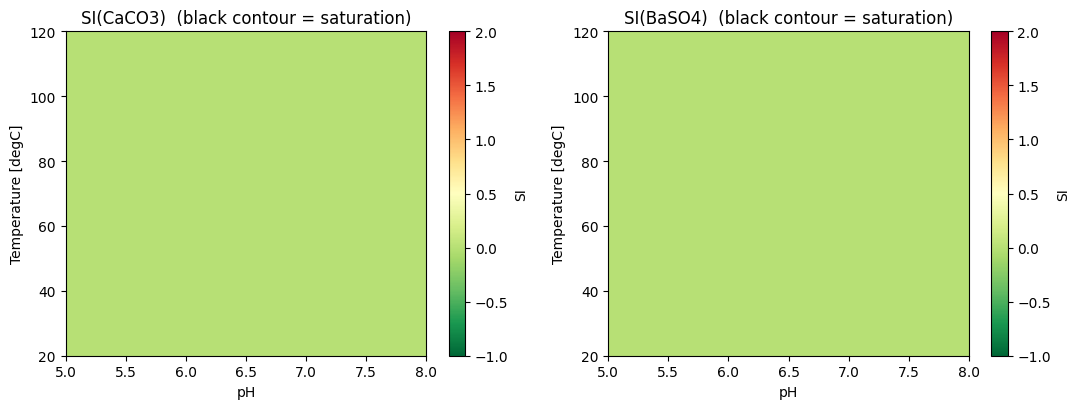

In [3]:
temps = np.linspace(20, 120, 11)
pHs = np.linspace(5.0, 8.0, 7)
SI_caco3 = np.zeros((len(temps), len(pHs)))
SI_baso4 = np.zeros_like(SI_caco3)

for i, T in enumerate(temps):
    for j, pH in enumerate(pHs):
        s = (Esc()
            .setTemperatureCelsius(T)
            .setPressureBara(120.0)
            .setPH(pH)
            .setCO2PartialPressureBar(4.0)
            .setCations(1500.0, 5.0, 80.0, 800.0, 12000.0, 400.0, 0.0)
            .setAnions(20000.0, 100.0, 400.0, 0.0))
        SI_caco3[i, j] = s.getCaCO3SaturationIndex()
        SI_baso4[i, j] = s.getBaSO4SaturationIndex()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, data, title in zip(axes, [SI_caco3, SI_baso4], ["SI(CaCO3)", "SI(BaSO4)"]):
    im = ax.imshow(data, origin="lower", aspect="auto",
                   extent=[pHs[0], pHs[-1], temps[0], temps[-1]],
                   cmap="RdYlGn_r", vmin=-1, vmax=2)
    ax.contour(pHs, temps, data, levels=[0.0], colors="black", linewidths=1.5)
    ax.set_xlabel("pH"); ax.set_ylabel("Temperature [degC]")
    ax.set_title(title + "  (black contour = saturation)")
    fig.colorbar(im, ax=ax, label="SI")
fig.tight_layout()
plt.show()


## 3. Seawater mixing — barite scaling along an injection well

Mix formation brine (high Ba, low SO4) with seawater (low Ba, ~2700 mg/L SO4) and look at SI(BaSO4) as a function of seawater fraction.

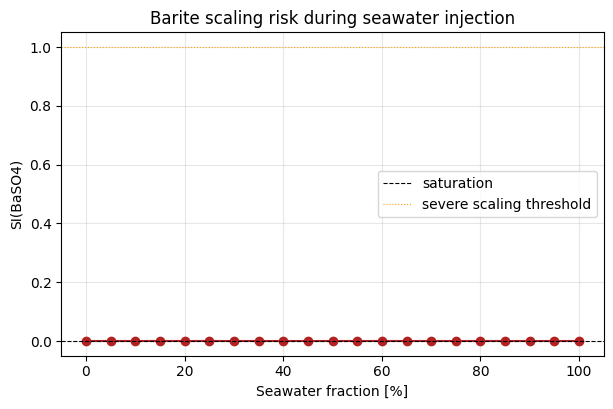

Worst-case at 0 % seawater: SI(BaSO4) = +0.00


In [4]:
def mix(ion_form, ion_sea, frac):
    return (1.0 - frac) * ion_form + frac * ion_sea

# formation: high Ba, low SO4
form = dict(Ca=1500, Ba=5, Sr=80, Mg=800, Na=12000, K=400, Fe=0,
            Cl=20000, SO4=100, HCO3=400, CO3=0)
# seawater (typical North Sea)
sea  = dict(Ca=400, Ba=0.05, Sr=8, Mg=1290, Na=10800, K=400, Fe=0,
            Cl=19400, SO4=2700, HCO3=140, CO3=0)

fracs = np.linspace(0.0, 1.0, 21)
SI_bar = []
for f in fracs:
    s = (Esc()
        .setTemperatureCelsius(80.0).setPressureBara(120.0)
        .setPH(6.5).setCO2PartialPressureBar(4.0)
        .setCations(mix(form["Ca"], sea["Ca"], f),
                    mix(form["Ba"], sea["Ba"], f),
                    mix(form["Sr"], sea["Sr"], f),
                    mix(form["Mg"], sea["Mg"], f),
                    mix(form["Na"], sea["Na"], f),
                    mix(form["K"],  sea["K"],  f), 0.0)
        .setAnions(mix(form["Cl"],  sea["Cl"],  f),
                   mix(form["SO4"], sea["SO4"], f),
                   mix(form["HCO3"], sea["HCO3"], f), 0.0))
    SI_bar.append(s.getBaSO4SaturationIndex())

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(fracs * 100, SI_bar, "o-", color="#b22222")
ax.axhline(0, color="black", ls="--", lw=0.8, label="saturation")
ax.axhline(1, color="orange", ls=":", lw=0.8, label="severe scaling threshold")
ax.set_xlabel("Seawater fraction [%]"); ax.set_ylabel("SI(BaSO4)")
ax.set_title("Barite scaling risk during seawater injection")
ax.grid(True, alpha=0.3); ax.legend()
plt.show()

i_max = int(np.argmax(SI_bar))
print(f"Worst-case at {fracs[i_max]*100:.0f} % seawater: SI(BaSO4) = {SI_bar[i_max]:+.2f}")


## 4. Interpretation

- The temperature x pH map shows the high-risk envelope for both carbonate and sulfate
  scales; the black saturation contour is the boundary across which inhibitor dosing
  becomes mandatory.
- The seawater mixing curve typically peaks at 20-40 % seawater because that is where
  Ba and SO4 concentrations are simultaneously high enough to maximise the IAP.
- For SI > 1 a phosphonate inhibitor is recommended downhole; SI > 2 typically requires
  a sub-surface (downhole) squeeze treatment.

See [`docs/chemistry/electrolyte_scale.md`](../../docs/chemistry/electrolyte_scale.md) for
the underlying Davies math and SI risk thresholds, and
[`closed_loop_deposition.md`](../../docs/chemistry/closed_loop_deposition.md) for translating
SI into pipe-ID shrinkage forecasts.
